In [1]:
import sys

sys.path.append("/home/robbe/MuMDIA")
from diann_feature_generator import DIANNFeatureGenerator, FeatureConfig
from test_diann_features import load_test_data

In [2]:
data_dict = load_test_data()

In [3]:
config = FeatureConfig(
    fragment_mass_tolerance=13.0,
    precursor_mass_tolerance=50.0,
    rt_tolerance=5.0,
    top_n_fragments=6,
    top_n_fragments_extended=12,
    n_jobs=1,  # Disable internal parallelization since we're parallelizing at precursor level
)

In [4]:
ms2pip_preds = data_dict["ms2pip_preds"]
deeplc_preds = data_dict["deeplc_preds"]
df_psms = data_dict["df_psms"]
df_fragment = data_dict["df_fragment"]
ms2dict = data_dict["ms2dict"]
ms1dict = data_dict["ms1_dict"]

In [5]:
df_psms

,psm_id,filename,scannr,peptide,stripped_peptide,proteins,num_proteins,rank,is_decoy,expmass,...,scored_candidates,poisson,sage_discriminant_score,posterior_error,spectrum_q,peptide_q,protein_q,reporter_ion_intensity,fragment_intensity,precursor
0,1573,part_0.0_783.2013244628906.mzml,controllerType=0 controllerNumber=1 scan=9771,AEGGSDER,AEGGSDER,sp|P10903|NARK_ECOLI|386|394,1,5,False,823.6175,...,10,-0.399090,0.635878,-9.144547,0.058824,0.327426,0.327594,NaN,5778.0884,AEGGSDER/1
1,1572,part_0.0_783.2013244628906.mzml,controllerType=0 controllerNumber=1 scan=9771,AGEKTYR,AGEKTYR,sp|P30126|LEUD_ECOLI|154|161,1,4,False,823.6175,...,10,-0.399090,0.582951,-6.169283,0.058824,0.327426,0.327594,NaN,5778.0884,AGEKTYR/1
2,135,part_0.0_783.2013244628906.mzml,controllerType=0 controllerNumber=1 scan=11454,TGGGAKGNNASPAGSGNTK,TGGGAKGNNASPAGSGNTK,sp|P19934|TOLA_ECOLI|309|328,1,3,False,1647.2350,...,10,-0.399090,0.569689,-5.489716,0.058824,0.327426,0.327594,NaN,14769.8490,TGGGAKGNNASPAGSGNTK/2
3,2241,part_0.0_783.2013244628906.mzml,controllerType=0 controllerNumber=1 scan=19582,AANTGPHAAR,AANTGPHAAR,sp|P0ADH5|FIMB_ECOLI|23|33,1,4,False,967.6829,...,4,-0.399090,0.427336,-0.671581,0.058824,0.327426,0.327594,NaN,6838.0205,AANTGPHAAR/1
4,2511,part_0.0_783.2013244628906.mzml,controllerType=0 controllerNumber=1 scan=8718,KPGSAAASGPK,KPGSAAASGPK,sp|P0AA80|GARP_ECOLI|228|239,1,5,False,967.6829,...,5,-0.399090,0.400636,-0.551443,0.058824,0.334264,0.334450,NaN,5298.7236,KPGSAAASGPK/1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6895736,28313250,part_8615.214569091797_9398.415893554688.mzml,controllerType=0 controllerNumber=1 scan=230359,GLPHNVATKGGVSSDVQSLLTTPVQIFR,GLPHNVATKGGVSSDVQSLLTTPVQIFR,rev_sp|P07639|AROB_ECOLI|212|240,1,15,True,2915.0542,...,15,-0.399090,-0.788482,-0.239177,0.998956,1.000000,1.000000,NaN,6062.3057,GLPHNVATKGGVSSDVQSLLTTPVQIFR/3
6895737,28323411,part_8615.214569091797_9398.415893554688.mzml,controllerType=0 controllerNumber=1 scan=235604,VSASNGYYPENLAFPSTKIFTSIFR,VSASNGYYPENLAFPSTKIFTSIFR,rev_sp|P04152|UMUC_ECOLI|112|137,1,37,True,2814.2515,...,73,-0.399090,-0.788485,-0.239167,0.998956,1.000000,1.000000,NaN,5381.6064,VSASNGYYPENLAFPSTKIFTSIFR/4
6895738,28314945,part_8615.214569091797_9398.415893554688.mzml,controllerType=0 controllerNumber=1 scan=229854,QRSLYIPYAGPVLLEFPLLNK,QRSLYIPYAGPVLLEFPLLNK,sp|P26616|MAO1_ECOLI|7|28,1,6,False,2446.0842,...,24,-0.407381,-0.788575,-0.238836,0.999536,1.000000,1.000000,NaN,6749.7075,QRSLYIPYAGPVLLEFPLLNK/4
6895739,28322986,part_8615.214569091797_9398.415893554688.mzml,controllerType=0 controllerNumber=1 scan=235515,IDVLQLAQVLRQTITK,IDVLQLAQVLRQTITK,rev_sp|P52140|YFJY_ECOLI|22|38,1,4,True,1834.5632,...,10,-0.399090,-0.788578,-0.238836,0.999652,1.000000,1.000000,NaN,8583.5570,IDVLQLAQVLRQTITK/3


In [6]:
precursor = df_psms[df_psms["precursor"] == "GAEQIYIPVLIK/2"]
precursor_fragments = df_fragment[df_fragment["psm_id"].isin(precursor["psm_id"])]
precursor_fragments["ppm_error"] = (
    abs(
        precursor_fragments["fragment_mz_calculated"]
        - precursor_fragments["fragment_mz_experimental"]
    )
    / precursor_fragments["fragment_mz_calculated"]
    * 1e6
)

/tmp/ipykernel_2843168/1917794545.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  precursor_fragments["ppm_error"] = (


In [7]:
precursor_fragments

,psm_id,fragment_type,fragment_ordinals,fragment_charge,fragment_mz_experimental,fragment_mz_calculated,fragment_intensity,peptide,charge,rt,scannr,fragment_names,ppm_error
13260945,22863186,b,3,1,258.10864,258.10840,1632843.600,GAEQIYIPVLIK,2,115.02221,controllerType=0 controllerNumber=1 scan=181050,b3,0.929842
13260946,22863186,b,4,1,386.16733,386.16700,827085.500,GAEQIYIPVLIK,2,115.02221,controllerType=0 controllerNumber=1 scan=181050,b4,0.854553
13260947,22863186,b,5,1,499.25272,499.25104,407361.280,GAEQIYIPVLIK,2,115.02221,controllerType=0 controllerNumber=1 scan=181050,b5,3.365041
13260948,22863186,b,6,1,662.31370,662.31440,179490.830,GAEQIYIPVLIK,2,115.02221,controllerType=0 controllerNumber=1 scan=181050,b6,1.056900
13260949,22863186,b,7,1,775.39905,775.39844,99320.600,GAEQIYIPVLIK,2,115.02221,controllerType=0 controllerNumber=1 scan=181050,b7,0.786692
...,...,...,...,...,...,...,...,...,...,...,...,...,...
16852928,24029435,y,5,1,569.40380,569.40210,17954.900,GAEQIYIPVLIK,2,120.94842,controllerType=0 controllerNumber=1 scan=190385,y5,2.985588
16867564,25157874,b,3,1,258.10870,258.10840,6979.220,GAEQIYIPVLIK,2,120.26560,controllerType=0 controllerNumber=1 scan=189312,b3,1.162302
16867565,25157874,y,5,1,569.40173,569.40210,7348.862,GAEQIYIPVLIK,2,120.26560,controllerType=0 controllerNumber=1 scan=189312,y5,0.649804
17024189,24205615,b,3,1,258.10840,258.10840,8374.344,GAEQIYIPVLIK,2,120.85130,controllerType=0 controllerNumber=1 scan=190232,b3,0.000000


In [8]:
feat_gen = DIANNFeatureGenerator(config=config)

INFO:diann_feature_generator:Using 1 workers for parallel feature calculation
INFO:diann_feature_generator:Initialized DIANNFeatureGenerator with built-in optimizations


In [9]:
precursor_fragments

,psm_id,fragment_type,fragment_ordinals,fragment_charge,fragment_mz_experimental,fragment_mz_calculated,fragment_intensity,peptide,charge,rt,scannr,fragment_names,ppm_error
13260945,22863186,b,3,1,258.10864,258.10840,1632843.600,GAEQIYIPVLIK,2,115.02221,controllerType=0 controllerNumber=1 scan=181050,b3,0.929842
13260946,22863186,b,4,1,386.16733,386.16700,827085.500,GAEQIYIPVLIK,2,115.02221,controllerType=0 controllerNumber=1 scan=181050,b4,0.854553
13260947,22863186,b,5,1,499.25272,499.25104,407361.280,GAEQIYIPVLIK,2,115.02221,controllerType=0 controllerNumber=1 scan=181050,b5,3.365041
13260948,22863186,b,6,1,662.31370,662.31440,179490.830,GAEQIYIPVLIK,2,115.02221,controllerType=0 controllerNumber=1 scan=181050,b6,1.056900
13260949,22863186,b,7,1,775.39905,775.39844,99320.600,GAEQIYIPVLIK,2,115.02221,controllerType=0 controllerNumber=1 scan=181050,b7,0.786692
...,...,...,...,...,...,...,...,...,...,...,...,...,...
16852928,24029435,y,5,1,569.40380,569.40210,17954.900,GAEQIYIPVLIK,2,120.94842,controllerType=0 controllerNumber=1 scan=190385,y5,2.985588
16867564,25157874,b,3,1,258.10870,258.10840,6979.220,GAEQIYIPVLIK,2,120.26560,controllerType=0 controllerNumber=1 scan=189312,b3,1.162302
16867565,25157874,y,5,1,569.40173,569.40210,7348.862,GAEQIYIPVLIK,2,120.26560,controllerType=0 controllerNumber=1 scan=189312,y5,0.649804
17024189,24205615,b,3,1,258.10840,258.10840,8374.344,GAEQIYIPVLIK,2,120.85130,controllerType=0 controllerNumber=1 scan=190232,b3,0.000000


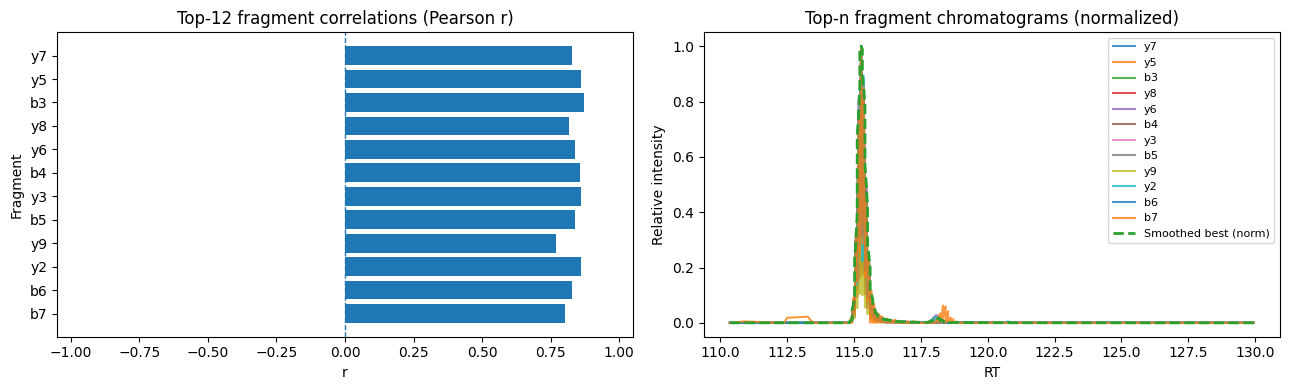

array([0.82767883, 0.86152661, 0.87015227, 0.81684683, 0.84013646,
       0.85565272, 0.85970058, 0.83864923, 0.76768729, 0.86093278,
       0.82596904, 0.80234844])

In [10]:
pearson_corr_top_n = feat_gen.feature_pearson_correlations_top_n(
    precursor_fragments, visualize=True
)
pearson_corr_top_n

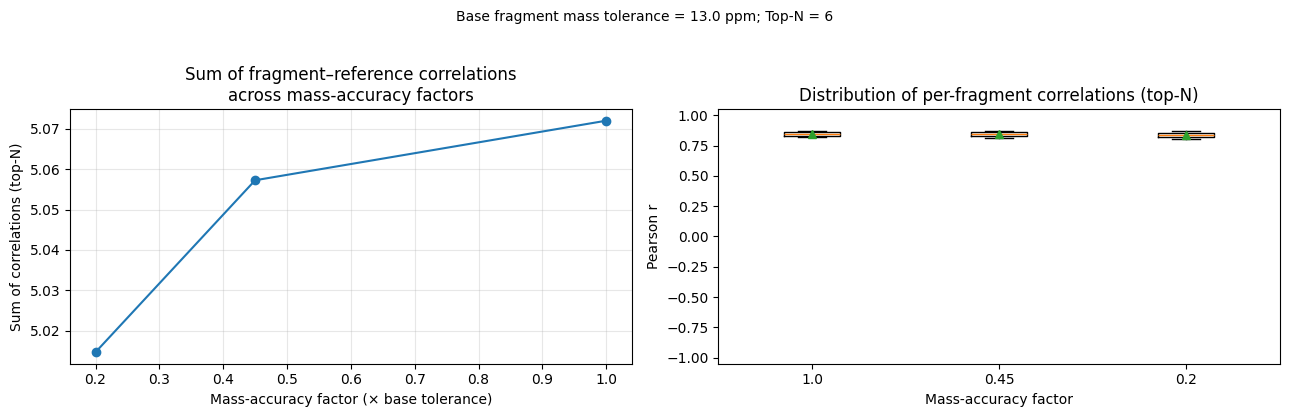

array([5.07199372, 5.05724783, 5.01469269])

In [11]:
result_arr = feat_gen.feature_sum_correlations_mass_accuracy(
    precursor_fragments, visualize=True
)
result_arr

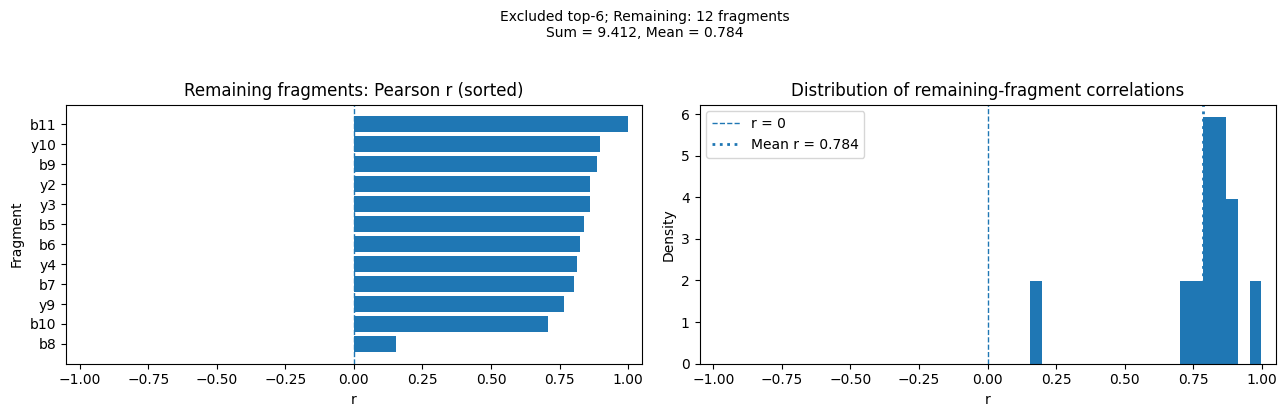

array([9.41191265, 0.78432605])

In [12]:
result_arr = feat_gen.feature_remaining_fragments_correlations(
    precursor_fragments, visualize=True
)
result_arr

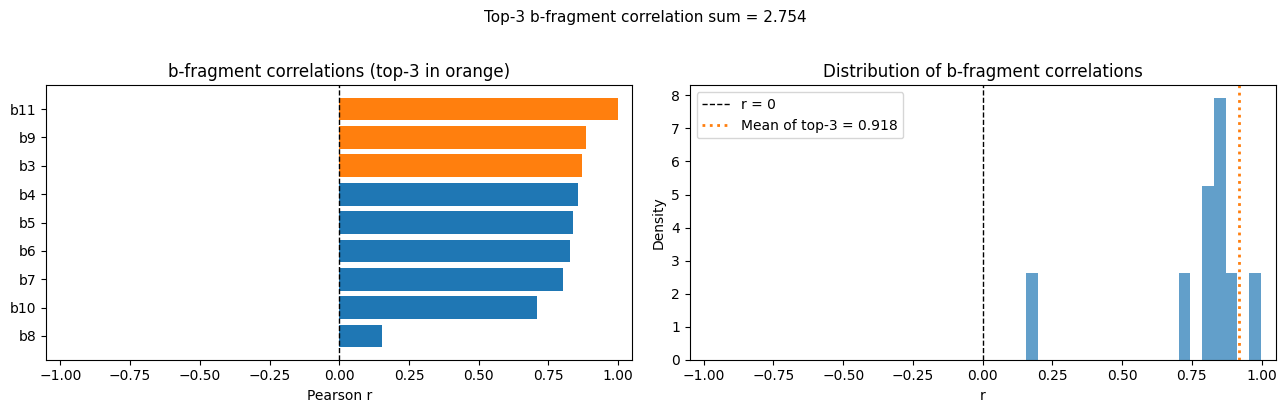

In [13]:
corr_sum = feat_gen.feature_best_b_fragments_correlation(
    precursor_fragments, visualize=True
)

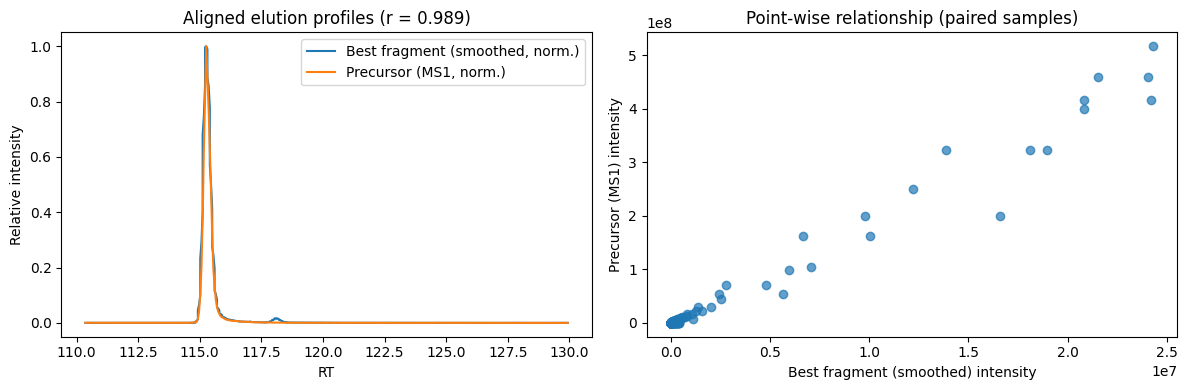

0.9893134002735157

In [14]:
correlation = feat_gen.feature_precursor_best_fragment_correlation(
    precursor, precursor_fragments, ms1dict, visualize=True
)
correlation

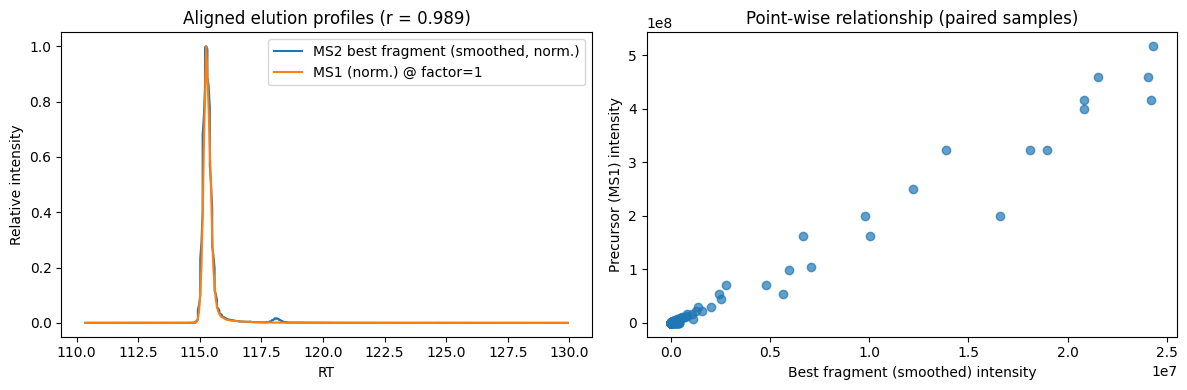

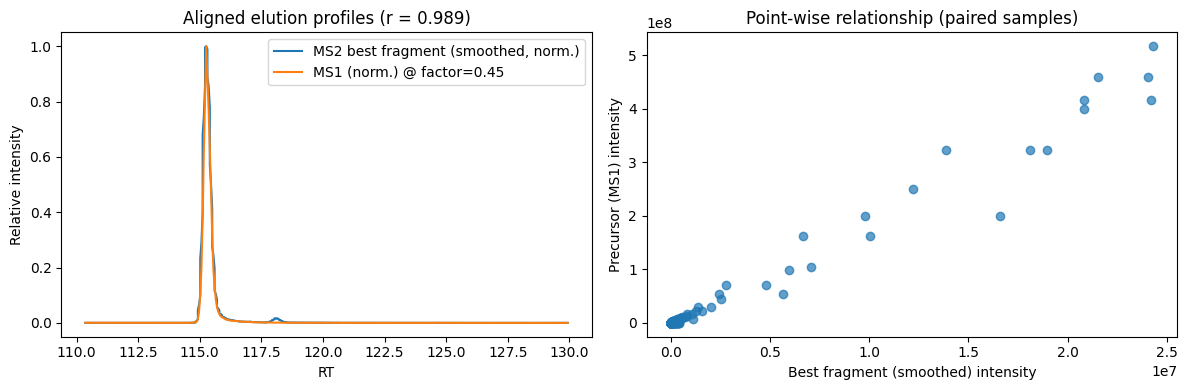

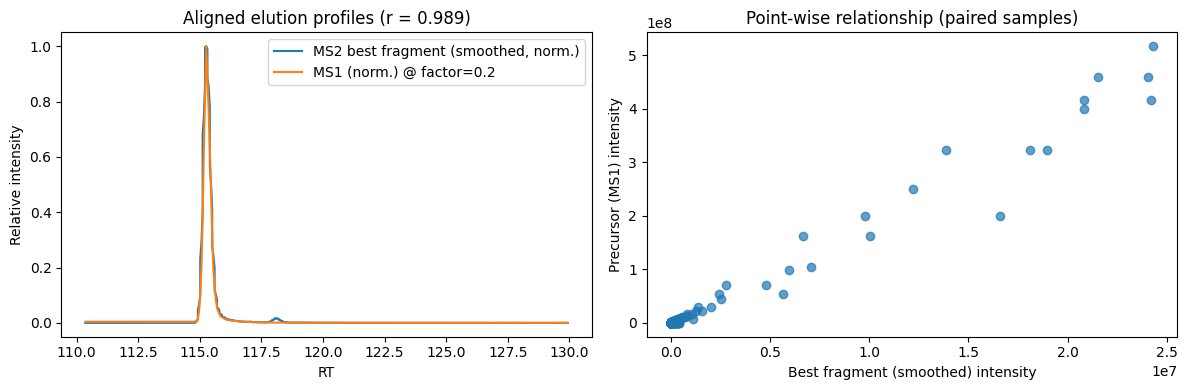

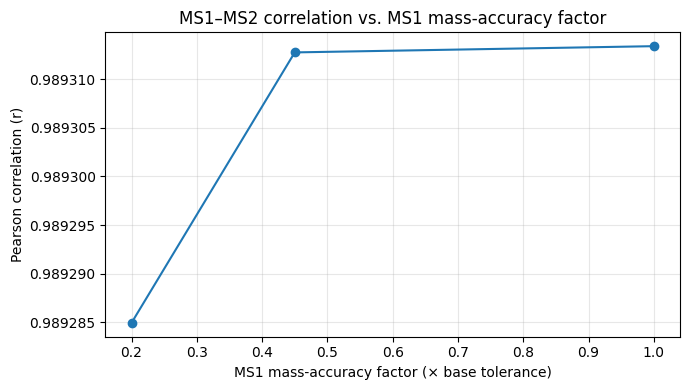

In [15]:
array_results = feat_gen.feature_ms1_accuracy_correlations(
    precursor, precursor_fragments, ms1dict, visualize=True, visualize_per_factor=True
)

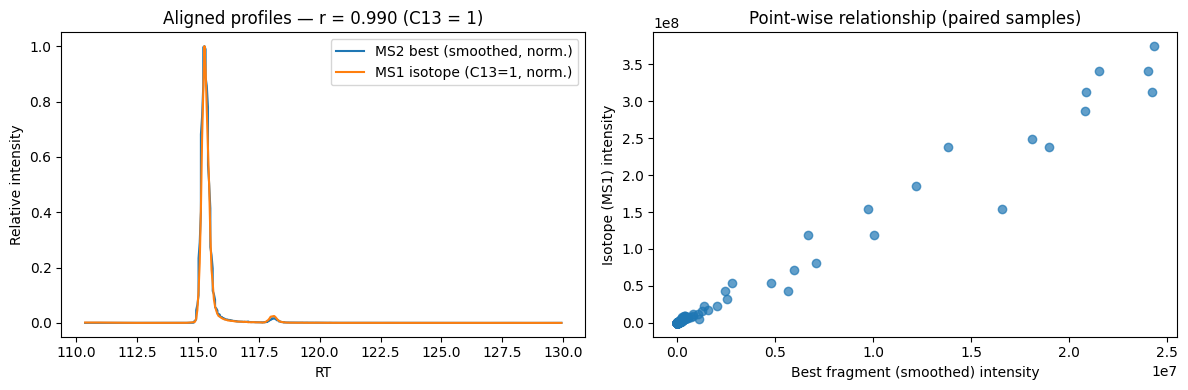

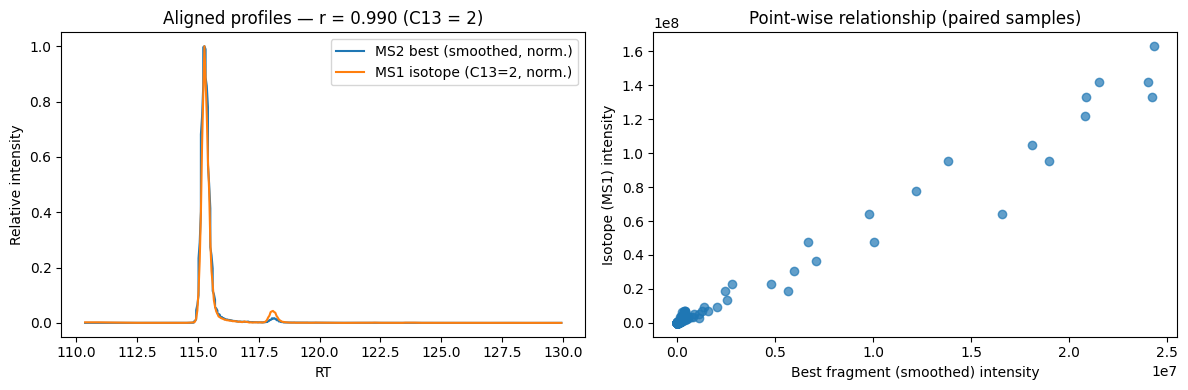

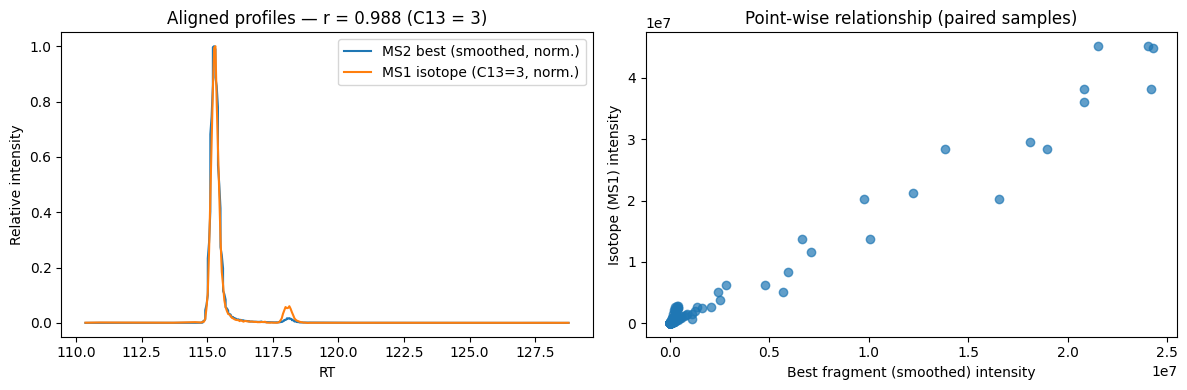

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


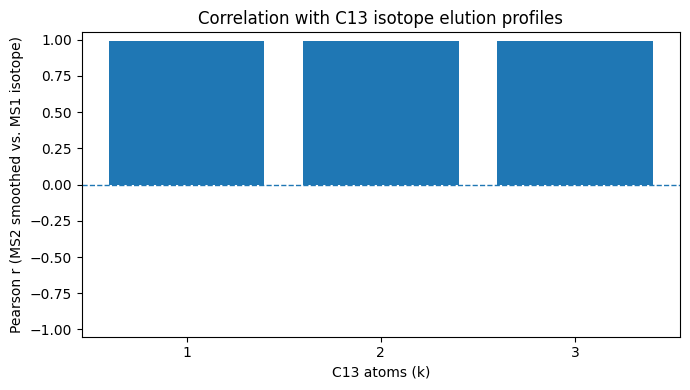

In [16]:
c13_corrs = feat_gen.feature_c13_isotope_correlations(
    precursor, precursor_fragments, ms1dict, visualize=True, visualize_per_isotope=True
)

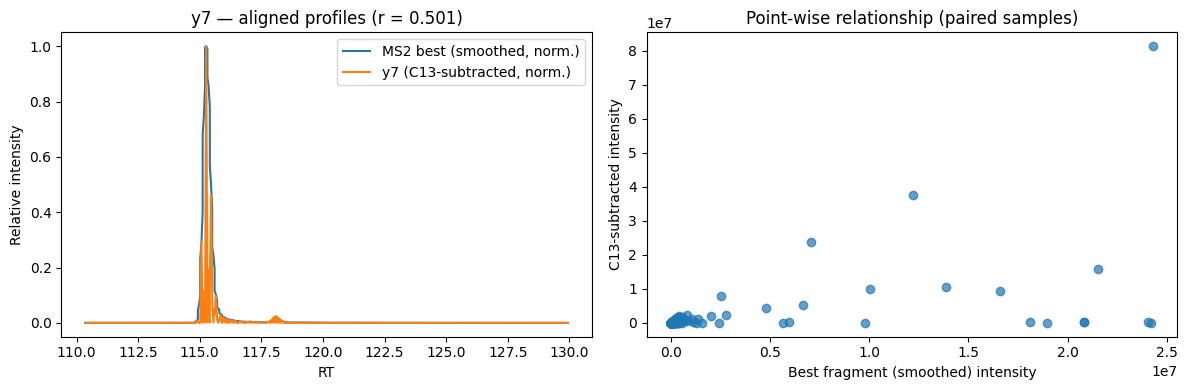

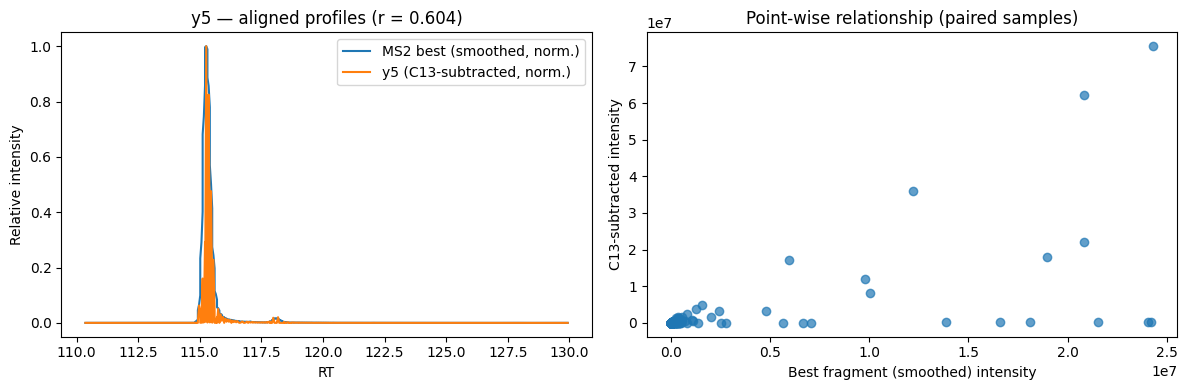

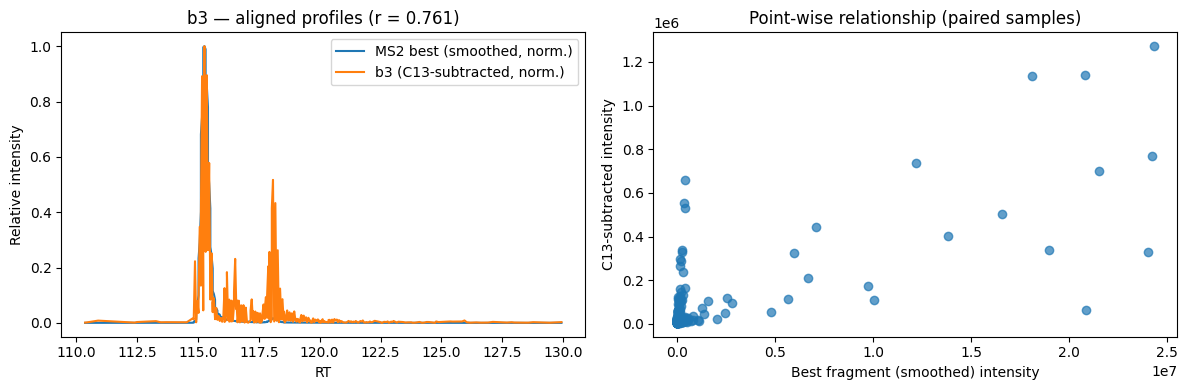

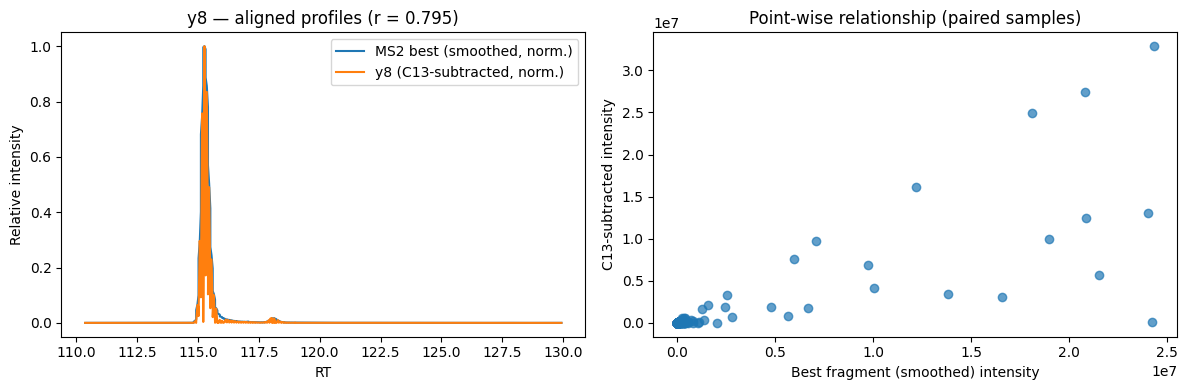

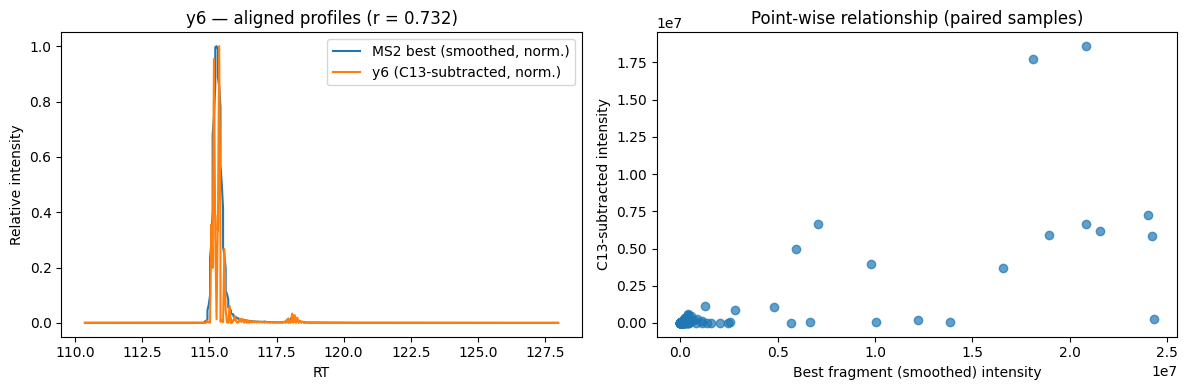

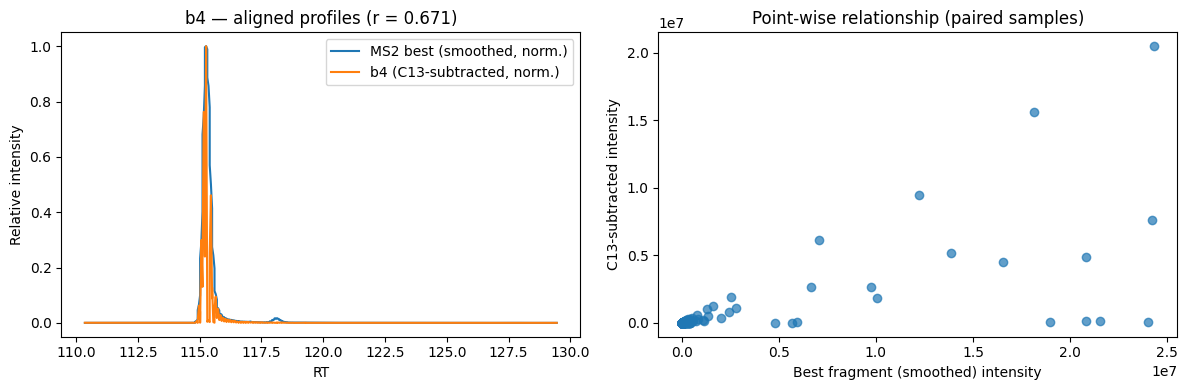

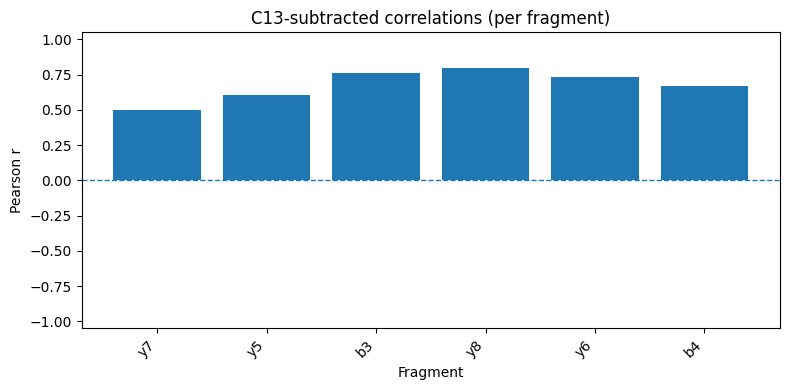

array([0.50148301, 0.60358949, 0.76141351, 0.79489284, 0.73245568,
       0.67058746])

In [17]:
corr_arr = feat_gen.feature_c13_subtracted_correlations(
    precursor_fragments, ms2dict, visualize=True, visualize_per_fragment=True
)
corr_arr

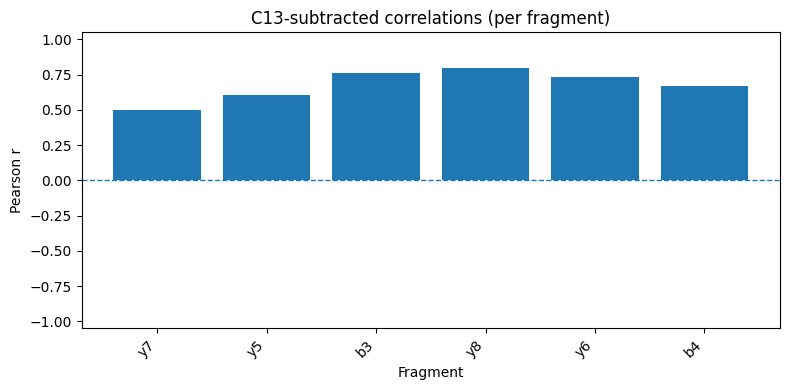

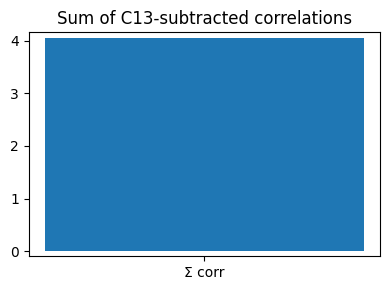

In [18]:
total = feat_gen.feature_sum_c13_subtracted_correlations(
    precursor_fragments, ms2dict, visualize=True
)

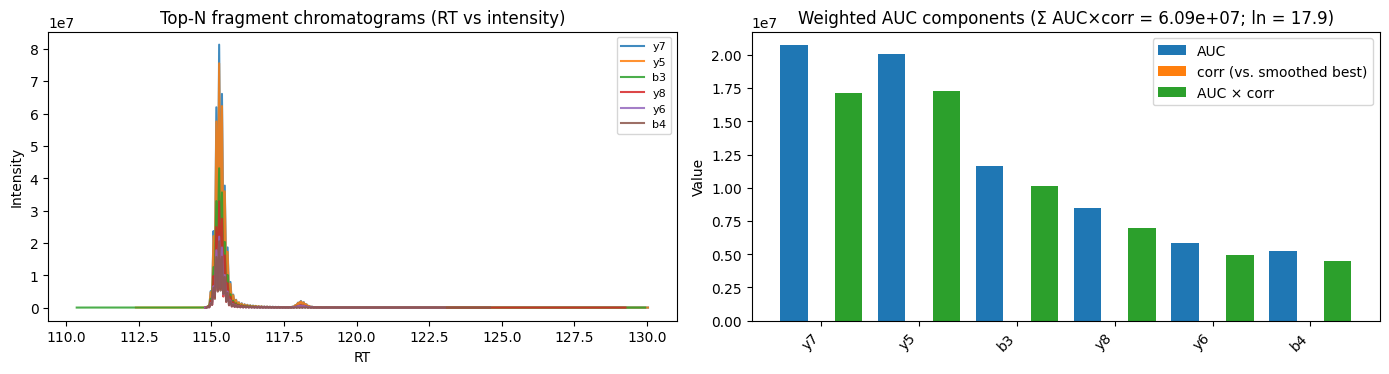

np.float64(17.923927996065476)

In [19]:
auc = feat_gen.feature_weighted_auc(precursor_fragments, visualize=True)
auc

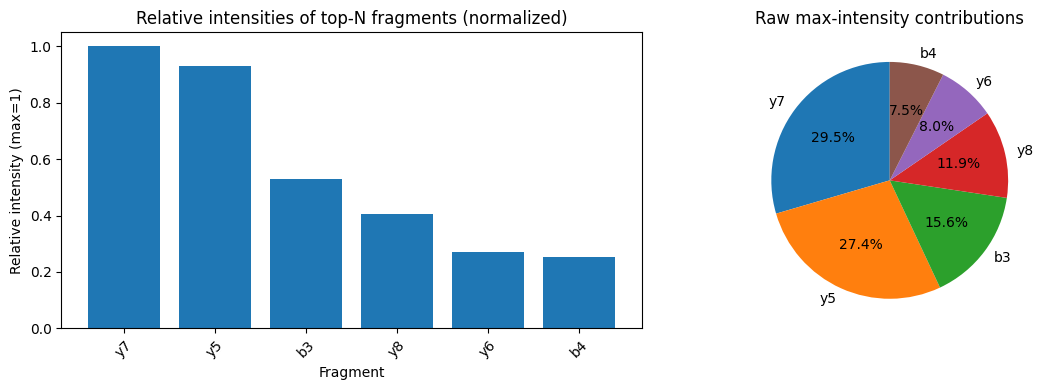

In [20]:
intensities = feat_gen.feature_relative_intensities_top_6(
    precursor_fragments, visualize=True
)

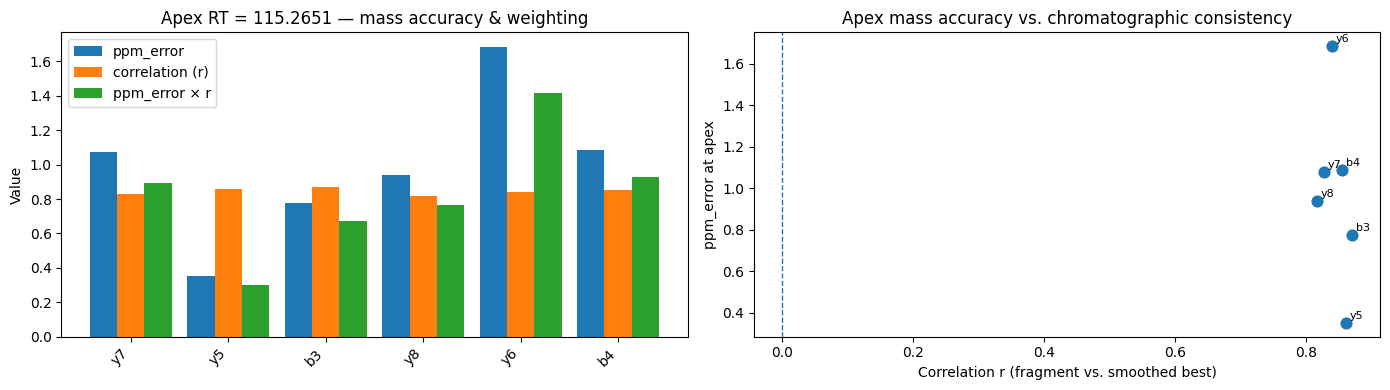

In [21]:
weighted_arr = feat_gen.feature_weighted_mass_accuracy(
    precursor_fragments, visualize=True
)

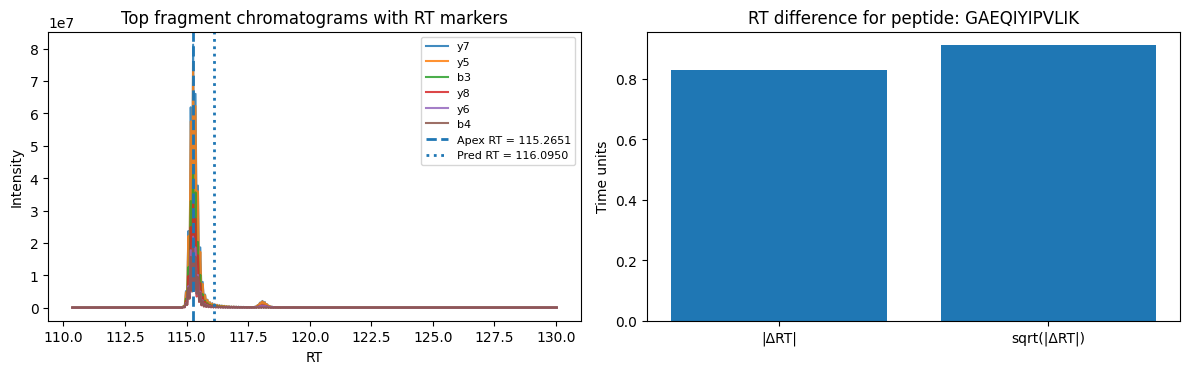

In [22]:
rt_result = feat_gen.feature_rt_prediction_difference(
    precursor_fragments, deeplc_preds, visualize=True
)

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


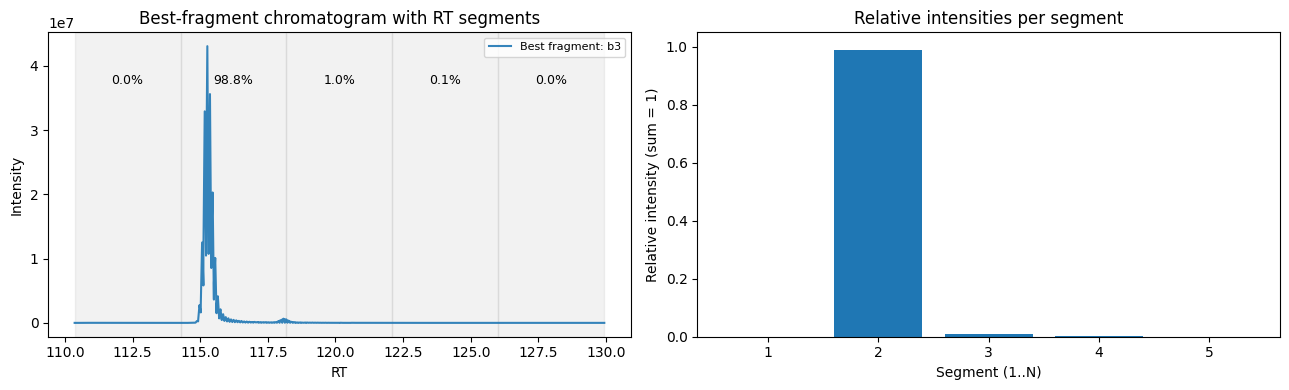

array([2.48026088e-04, 9.87761596e-01, 1.04720962e-02, 1.10124332e-03,
       4.17038413e-04])

In [23]:
array_splits = feat_gen.feature_scanning_window_splits(
    precursor_fragments, visualize=True
)

array_splits

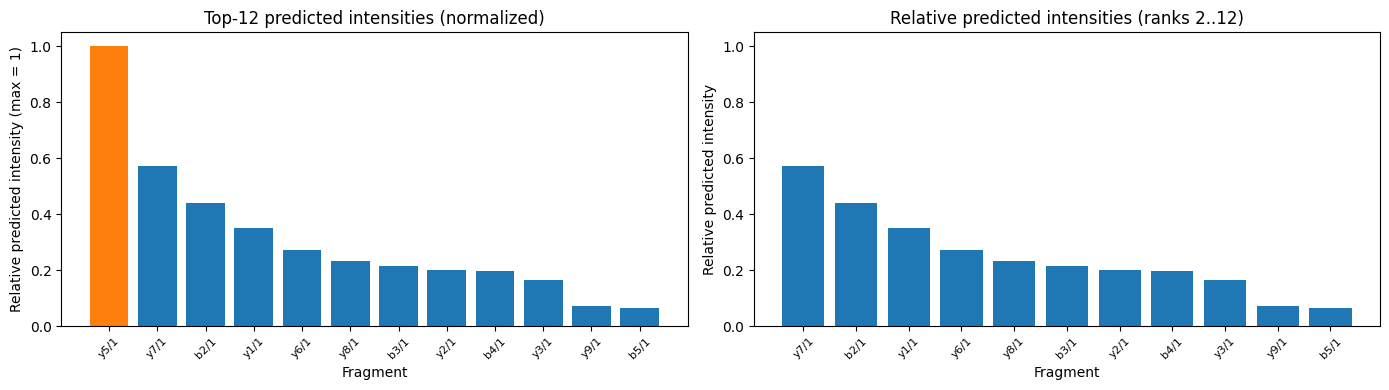

In [24]:
pred_ints = feat_gen.feature_relative_predicted_intensities(
    precursor_fragments, ms2pip_preds, visualize=True
)

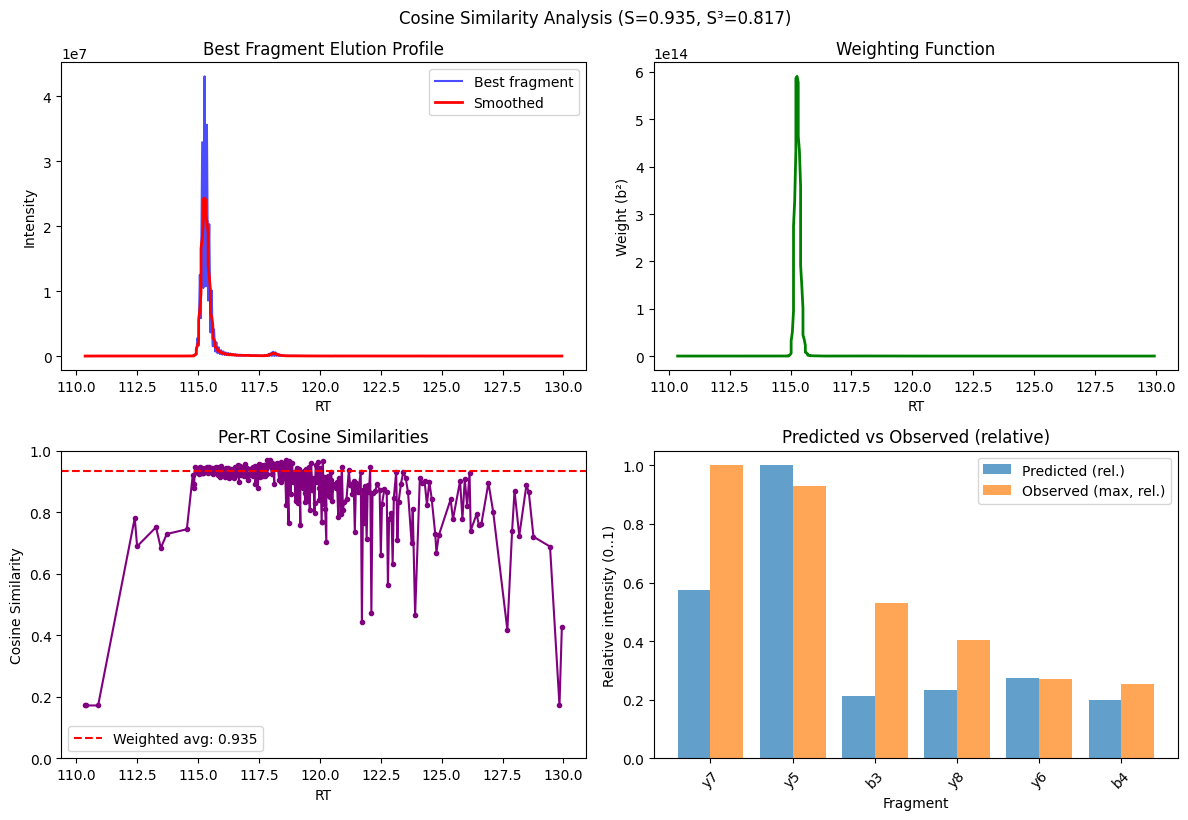

In [25]:
feat_array = feat_gen.feature_cos_pred_obs_weighted(
    precursor_fragments, ms2pip_preds, visualize=True, use_all_rt=True
)

In [27]:
mz = feat_gen.feature_precursor_mz(precursor)
mz

np.float64(672.4002760000001)